# 1. Dataset Loading and Initial Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Let's look at the first 5 lines.
df=pd.read_csv("ecommerce_customer_data_large.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [2]:
# We examine the column names, data types, and the presence of null values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [4]:
# We see the number of rows and columns.
df.shape

(250000, 13)

In [5]:
# We are looking at the statistical data.
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


# 2. Data Cleaning and Preprocessing


In [7]:
# We check how many null values ​​are in each column.
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [3]:
# Returns -	47382 ,we fill the empty values ​​in the 'Returns' column with 0.
df["Returns"]=df["Returns"].fillna(0)

In [4]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,0
Customer Name,0


In [5]:
# We are checking the number of repeated lines.
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# 3. RFM Analysis and Feature Engineering

In [6]:
# We convert the "Purchase Date" column to the date format.
df["Purchase Date"]=pd.to_datetime(df["Purchase Date"])

In [7]:
# We are creating a reference date for the analysis.
reference_date=df["Purchase Date"].max()+pd.Timedelta(days=1)
print("Reference Date:", reference_date)

Reference Date: 2023-09-14 18:42:49


In [8]:
# We calculate the number of days since each customer's last purchase.
recency = df.groupby("Customer ID")["Purchase Date"].max().reset_index()

recency["Recency"] = (
    reference_date - recency["Purchase Date"]
).dt.days

recency = recency[["Customer ID", "Recency"]]

recency.head()

,Customer ID,Recency
0,1,289
1,2,73
2,3,223
3,4,442
4,5,425


In [9]:
# We calculate the number of purchases for each customer.
frequency = df.groupby("Customer ID")["Purchase Date"].count().reset_index()

frequency.columns = ["Customer ID", "Frequency"]

frequency.head()

,Customer ID,Frequency
0,1,3
1,2,6
2,3,4
3,4,5
4,5,5


In [10]:
# We calculate the total amount spent by each customer.
monetary = df.groupby("Customer ID")["Total Purchase Amount"].sum().reset_index()

monetary.columns = ["Customer ID", "Monetary"]

monetary.head()

,Customer ID,Monetary
0,1,6290
1,2,16481
2,3,9423
3,4,7826
4,5,9769


In [11]:
# We combine Recency, Frequency, and Monetary data.
rfm = recency.merge(frequency, on="Customer ID")
rfm = rfm.merge(monetary, on="Customer ID")

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,1,289,3,6290
1,2,73,6,16481
2,3,223,4,9423
3,4,442,5,7826
4,5,425,5,9769


# 4. Descriptive Statistics

In [12]:
# We present statistical data on RFM metrics.
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,49661.000000,49661.000000,49661.000000,49661.000000
mean,24993.104488,262.335374,5.034131,13719.947222
std,14434.429306,246.804539,2.199399,6811.065854
min,1.000000,1.000000,1.000000,125.000000
25%,12494.000000,78.000000,3.000000,8718.000000
50%,24987.000000,187.000000,5.000000,13008.000000
75%,37492.000000,371.000000,6.000000,17921.000000
max,50000.000000,1352.000000,17.000000,50659.000000


In [13]:
print(f"Average Recency:  {rfm["Recency"].mean().round(2)}")
print(f"Average Frequency:  {rfm["Frequency"].mean().round(2)}")
print(f"Average Monetary:  {rfm["Monetary"].mean().round(2)}")

Average Recency:  262.34
Average Frequency:  5.03
Average Monetary:  13719.95


# 5. Feature Selection and Standardization

In [14]:
# We select the key behavioral features for K-Means.
features=rfm[["Recency","Frequency","Monetary"]]
features.head()

,Recency,Frequency,Monetary
0,289,3,6290
1,73,6,16481
2,223,4,9423
3,442,5,7826
4,425,5,9769


In [15]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
feature_scaler=scaler.fit_transform(features)

# 6. Determining the Optimal Number of Clusters

In [16]:
from sklearn.cluster import KMeans
inertia=[]
for k in range(2,11):
  kmeans=KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10
  )
  kmeans.fit(feature_scaler)
  inertia.append(kmeans.inertia_)


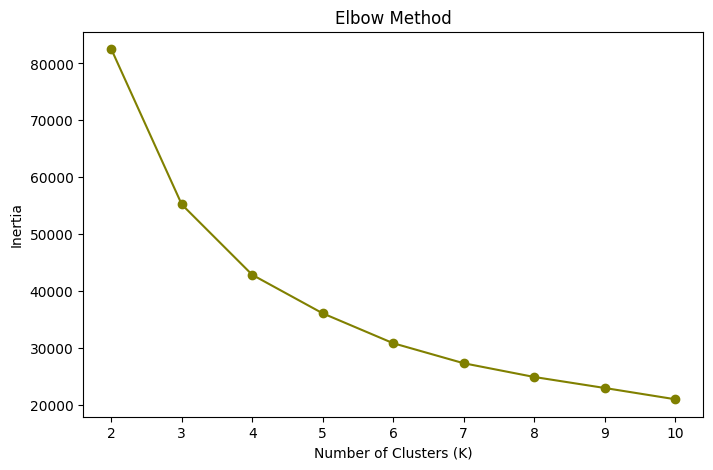

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    inertia,
    marker="o",
    color="olive"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# 7. K-Means Customer Segmentation

In [19]:
optimal_k=4
kmeans=KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
rfm["cluster"]=kmeans.fit_predict(feature_scaler)
rfm.head()


,Customer ID,Recency,Frequency,Monetary,cluster
0,1,289,3,6290,2
1,2,73,6,16481,3
2,3,223,4,9423,2
3,4,442,5,7826,2
4,5,425,5,9769,2


# 8. Cluster Visualization

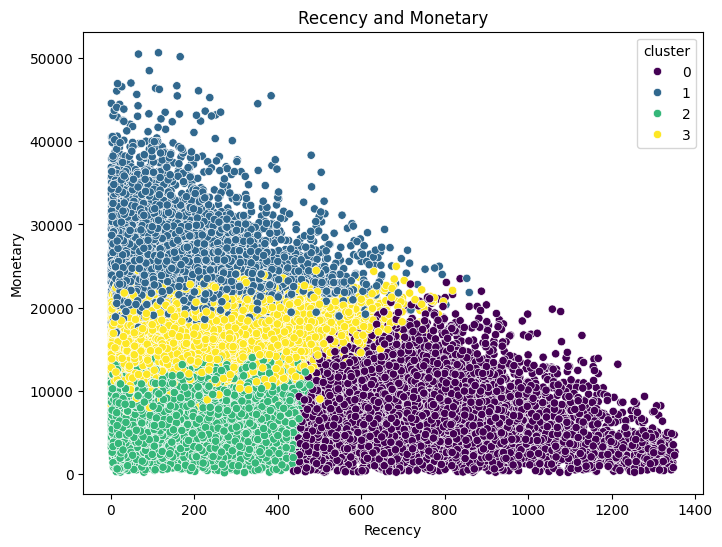

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="cluster",
    palette="viridis"
)
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Recency and Monetary")
plt.show()

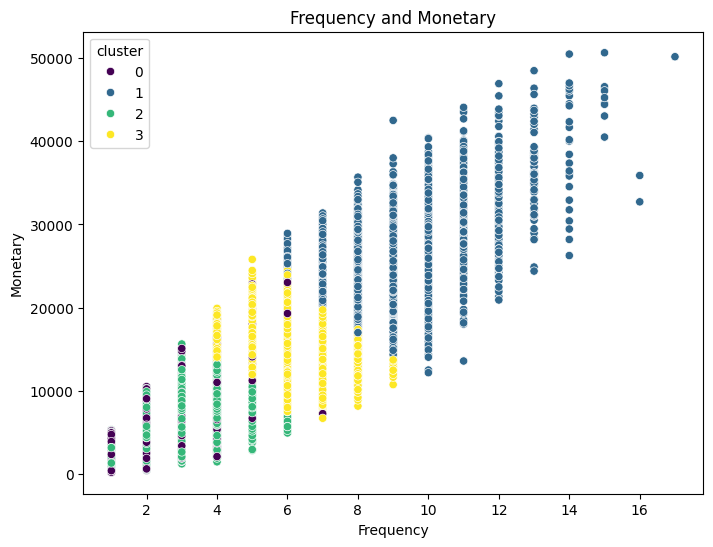

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="cluster",
    palette="viridis"
)
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Frequency and Monetary")
plt.show()

# 9. Cluster Profiling and Customer Segments

In [26]:
# We calculate the average RFM metrics for each cluster.
cluster_profile = rfm.groupby("cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()
cluster_profile

,Recency,Frequency,Monetary
cluster,,,
0,723.222325,2.922905,7801.511861
1,140.486644,8.458111,24490.669136
2,198.002829,3.375156,8406.965985
3,181.002951,5.733501,15702.639768


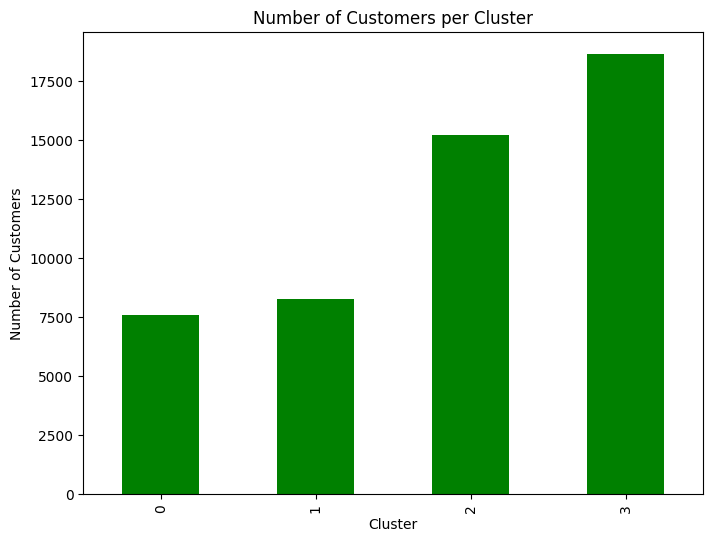

In [27]:
# We calculate the number of customers in each cluster.
cluster_counts = rfm["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind="bar",color="green")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers per Cluster")
plt.show()

In [28]:
cluster_counts

,count
cluster,
0,7588
1,8236
2,15199
3,18638


# 10. Business Insights and Marketing Recommendations

The K-Means algorithm divided the customers into four different groups based on their Recency, Frequency, and Monetary values. Each group has different customer behavior.

### Cluster 0 — Inactive Customers

Cluster 0 has a very high Recency value (**723.22 days**). Its Frequency (**2.92**) and Monetary value (**7,801.51**) are also low. This means that these customers have not purchased anything for a long time and are not very active.

**Marketing recommendation:** The company can send special discounts, promotional codes, and personalized offers to encourage these customers to come back.

### Cluster 1 — Loyal Customers

Cluster 1 has the lowest Recency value (**140.49 days**) and the highest Frequency (**8.46**) and Monetary value (**24,490.67**). This means that these customers buy more often and spend more money.

**Marketing recommendation:** The company should keep these customers by offering loyalty rewards, special discounts, and VIP offers.

### Cluster 2 — Low-Activity Customers

Cluster 2 has a Recency value of **198.00 days**, Frequency of **3.38**, and Monetary value of **8,406.97**. These customers do not purchase very often and have a lower spending level.

**Marketing recommendation:** The company can use discounts, product recommendations, and special offers to encourage them to buy more often.

### Cluster 3 — Active Customers

Cluster 3 is the largest group, with **18,638 customers**. It has a Recency value of **181.00 days**, Frequency of **5.73**, and Monetary value of **15,702.64**. These customers are relatively active and have good potential to become more valuable customers.

**Marketing recommendation:** The company can use personalized recommendations, cross-selling, upselling, and loyalty campaigns to increase their spending.

### Overall Insight

The analysis shows that customers have different purchasing behaviors. Therefore, the company should use different marketing strategies for each group. The company should focus on keeping loyal customers in Cluster 1, increasing the activity of Cluster 2 and Cluster 3, and bringing inactive customers in Cluster 0 back to the company.
